In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### DataLoading

In [2]:
df=pd.read_csv('../datasets/cars_data.csv')

In [3]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Feature Engineering

In [9]:
df['car_age']=2025-df['Year']

In [10]:
df['KMs_per_year']=df['Driven_kms']/df['car_age']

In [11]:
df['KMs_per_year']=round(df['KMs_per_year'],2)

In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age,KMs_per_year
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2454.55
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,3583.33
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,862.50
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,371.43
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,3859.09


### Exploratory Data Analysis

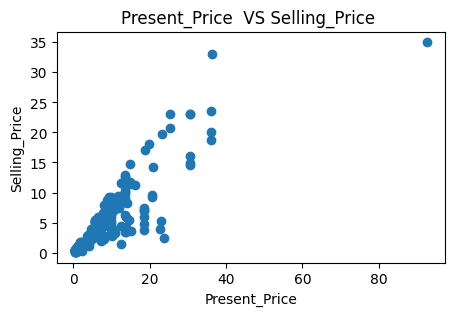

In [13]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='Present_Price',
            y='Selling_Price')
plt.xlabel("Present_Price")
plt.ylabel("Selling_Price")
plt.title("Present_Price  VS Selling_Price ")
plt.show()

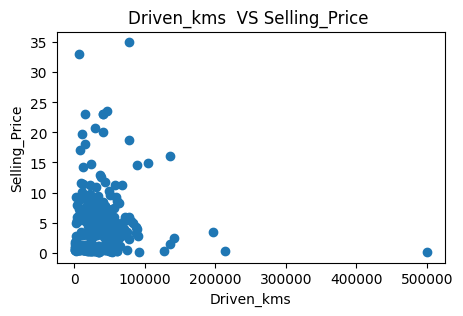

In [14]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='Driven_kms',
            y='Selling_Price')
plt.xlabel("Driven_kms")
plt.ylabel("Selling_Price")
plt.title("Driven_kms  VS Selling_Price ")
plt.show()

C:\Users\nikhi\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


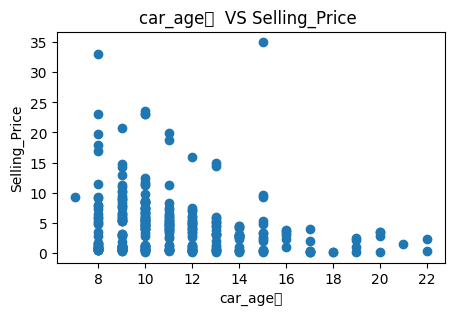

In [15]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='car_age',
            y='Selling_Price')
plt.xlabel("car_age	")
plt.ylabel("Selling_Price")
plt.title("car_age	  VS Selling_Price ")
plt.show()

In [16]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [17]:
df['Transmission'].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [18]:
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner,car_age,KMs_per_year
Year,1.000000,0.236141,-0.047192,-0.524342,-0.182104,-1.000000,-0.346763
Selling_Price,0.236141,1.000000,0.878914,0.029187,-0.088344,-0.236141,0.134574
Present_Price,-0.047192,0.878914,1.000000,0.203618,0.008058,0.047192,0.260111
Driven_kms,-0.524342,0.029187,0.203618,1.000000,0.089216,0.524342,0.954140
Owner,-0.182104,-0.088344,0.008058,0.089216,1.000000,0.182104,0.036272
car_age,-1.000000,-0.236141,0.047192,0.524342,0.182104,1.000000,0.346763
KMs_per_year,-0.346763,0.134574,0.260111,0.954140,0.036272,0.346763,1.000000


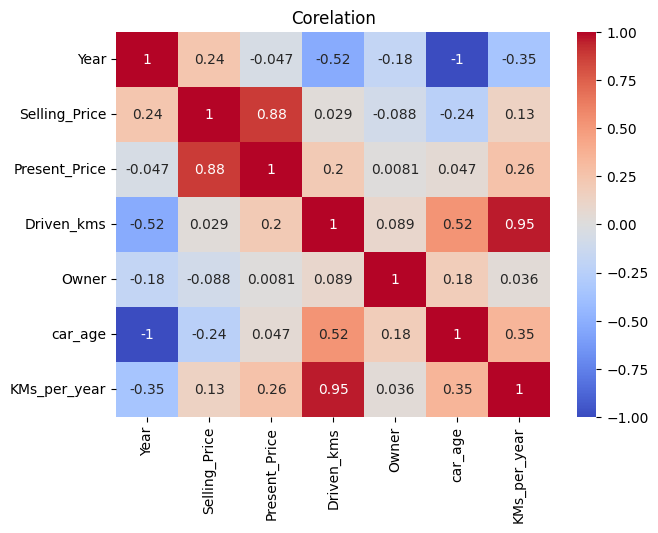

In [19]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Corelation")
plt.show()

In [22]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'car_age',
       'KMs_per_year'],
      dtype='object')

In [23]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age,KMs_per_year
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2454.55
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,3583.33
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,862.50
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,371.43
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,3859.09


### One Hot Encoding

In [24]:
df=pd.get_dummies(data=df,
                  columns=['Fuel_Type','Transmission','Selling_type'],
                  drop_first=True)


In [30]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)

In [31]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Owner,car_age,KMs_per_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual,Selling_type_Individual
0,ritz,2014,3.35,5.59,27000,0,11,2454.55,0,1,1,0
1,sx4,2013,4.75,9.54,43000,0,12,3583.33,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,0,8,862.50,0,1,1,0
3,wagon r,2011,2.85,4.15,5200,0,14,371.43,0,1,1,0
4,swift,2014,4.60,6.87,42450,0,11,3859.09,1,0,1,0


### Data Separation

In [32]:
df.drop('Car_Name',axis=1,inplace=True)

In [34]:
X=df.drop("Selling_Price",axis=1)

In [35]:
y=df['Selling_Price']

In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## Model Building

### Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
lr = LinearRegression()

lr.fit(X_train_scaled,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred=lr.predict(X_test_scaled)


In [44]:
pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

,Actual,Predicted
177,0.35,2.842588
289,10.11,8.318466
228,4.95,6.491954
198,0.15,-1.520682
60,6.95,9.048577
...,...,...
234,5.50,4.665289
296,9.50,8.954144
281,2.10,1.854093
285,7.40,7.672866


#### Model Evaluation

In [45]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score


MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
MAPE=mean_absolute_percentage_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

In [47]:
print(MAE)
print(MSE)
print(MAPE)
print(r2)

1.2260695641348653
3.4767241559569704
0.8298264438823352
0.8490715895272987


### Decision Tree

In [67]:
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(random_state=42)


In [68]:
dt.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [69]:
y_pred_dt=dt.predict(X_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

MAE = mean_absolute_error(y_test, y_pred_dt)
MSE = mean_squared_error(y_test, y_pred_dt)
RMSE = np.sqrt(MSE)
MAPE = mean_absolute_percentage_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("MAPE:", MAPE)
print("R2:", r2)

MAE: 0.8599999999999999
MSE: 2.0802295081967213
RMSE: 1.4423000756419315
MAPE: 0.21087188165386692
R2: 0.9096949545011801


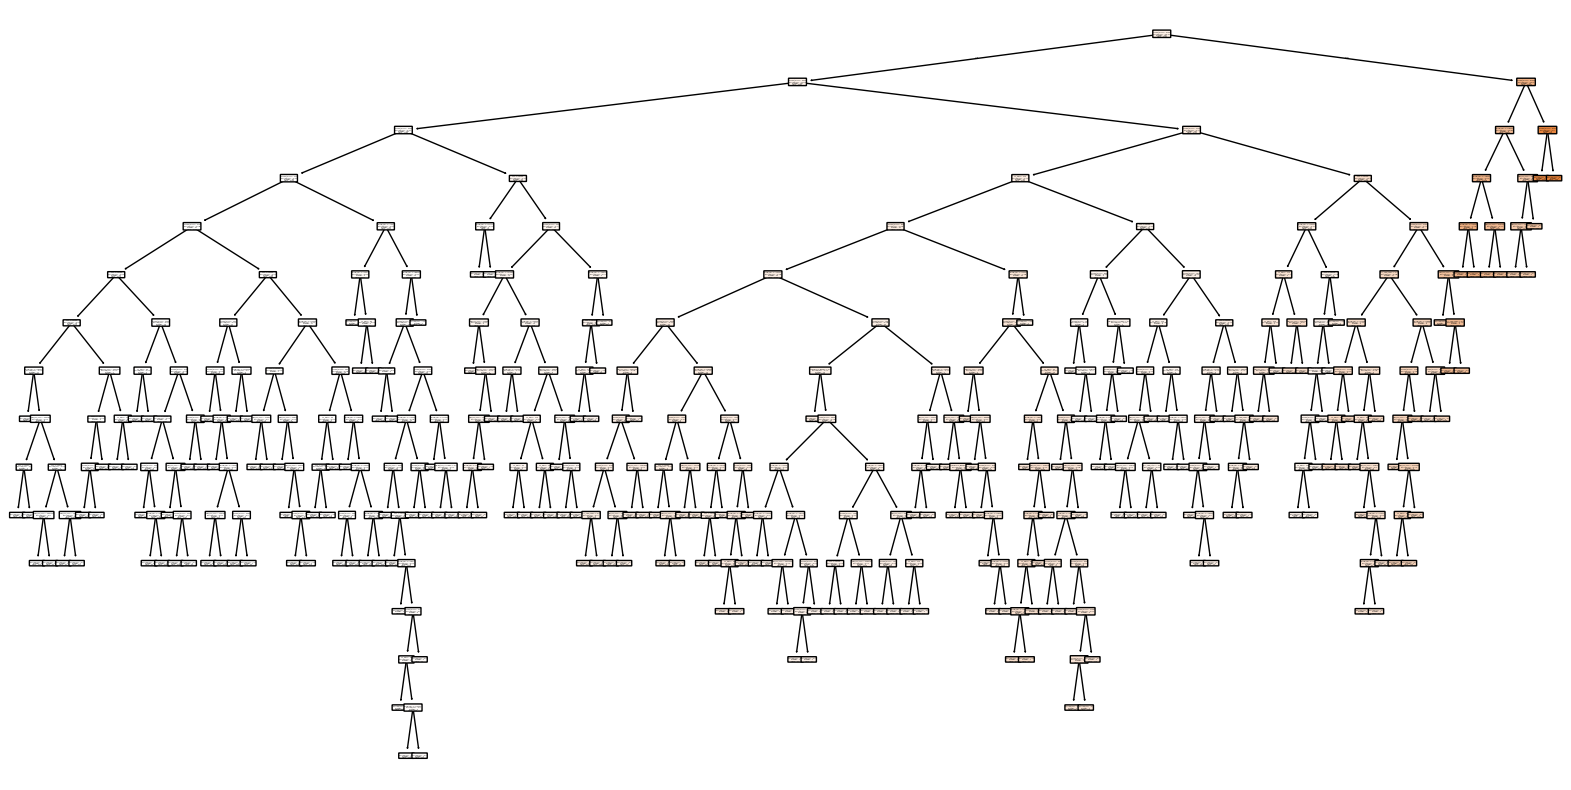

In [71]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.show()

### Randomforest

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [58]:
MAE = mean_absolute_error(y_test, y_pred_rf)
MSE = mean_squared_error(y_test, y_pred_rf)
RMSE = np.sqrt(MSE)
MAPE = mean_absolute_percentage_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

In [59]:
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("MAPE:", MAPE)
print("R2:", r2)

MAE: 0.631988524590164
MSE: 0.9008823509836053
RMSE: 0.9491482239269087
MAPE: 0.17783512980235808
R2: 0.9608917086436384
